# **Time Series Analysis**

Fuentes:
- https://www.kaggle.com/code/prashant111/complete-guide-on-time-series-analysis-in-python
- https://machinelearningmastery.com/decompose-time-series-data-trend-seasonality/

## **Instalación de dependencias**



In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import matplotlib as mpl
import matplotlib.pyplot as plt   # data visualization
import seaborn as sns             # statistical data visualization


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## **Importación de datos**

Datos: https://www.kaggle.com/datasets/rakannimer/air-passengers

In [ ]:
path = '/content/AirPassengers.csv'

df = pd.read_csv(path)

df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


Vamos a cambiar el nombre de la columna

In [ ]:
df.columns = ['Date','Number of Passengers']

df.head()

,Date,Number of Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


## **Visualizar la serie temporal**

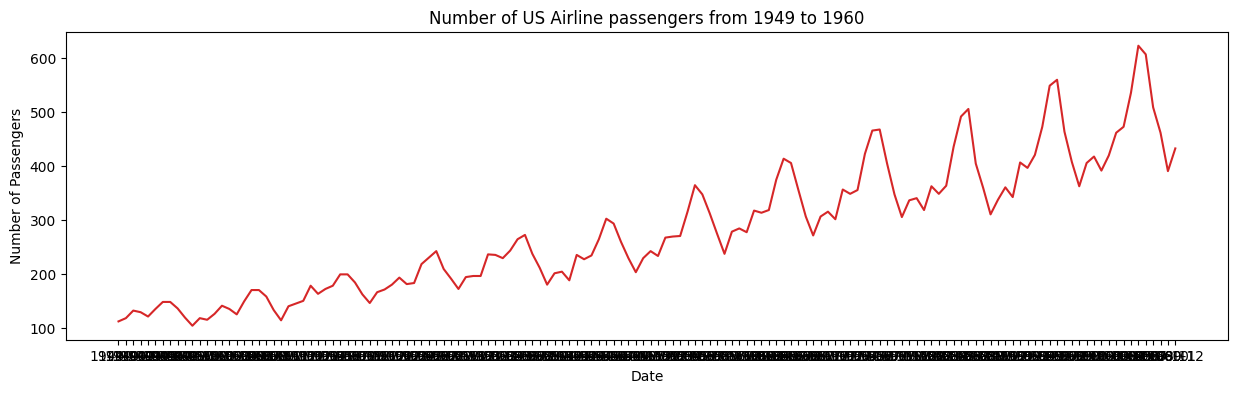

In [ ]:
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Number of Passengers', dpi=100):
    plt.figure(figsize=(15,4), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()


plot_df(df, x=df['Date'], y=df['Number of Passengers'], title='Number of US Airline passengers from 1949 to 1960')

Dado que todos los valores son positivos, podemos mostrar esto en ambos lados del eje Y para enfatizar el crecimiento.

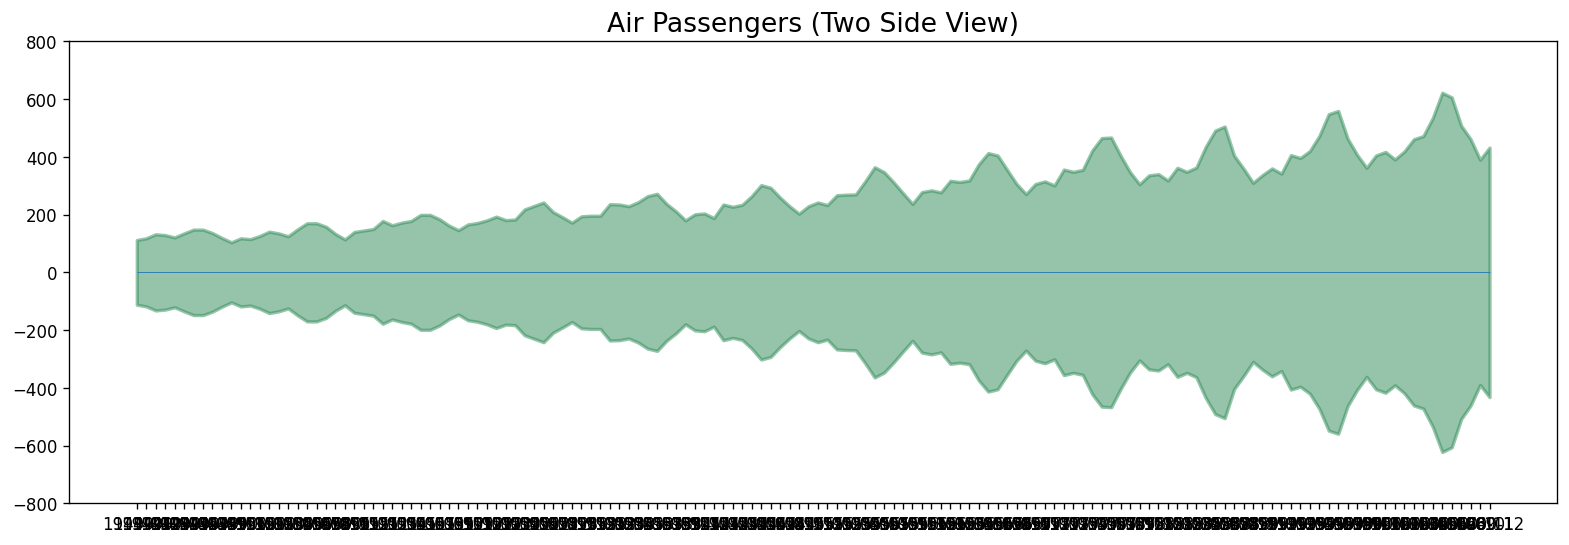

In [ ]:
x = df['Date'].values
y1 = df['Number of Passengers'].values

# Plot
fig, ax = plt.subplots(1, 1, figsize=(16,5), dpi= 120)
plt.fill_between(x, y1=y1, y2=-y1, alpha=0.5, linewidth=2, color='seagreen')
plt.ylim(-800, 800)
plt.title('Air Passengers (Two Side View)', fontsize=16)
plt.hlines(y=0, xmin=np.min(df['Date']), xmax=np.max(df['Date']), linewidth=.5)
plt.show()

## **Patrones en una serie de tiempo**

Cualquier visualización de serie temporal puede constar de los siguientes componentes: Nivel base + Tendencia + Estacionalidad + Error

Sin embargo, no es obligatorio que todas las series temporales tengan tendencia y/o estacionalidad. Una serie de tiempo puede no tener una tendencia definida pero sí una estacionalidad y viceversa.

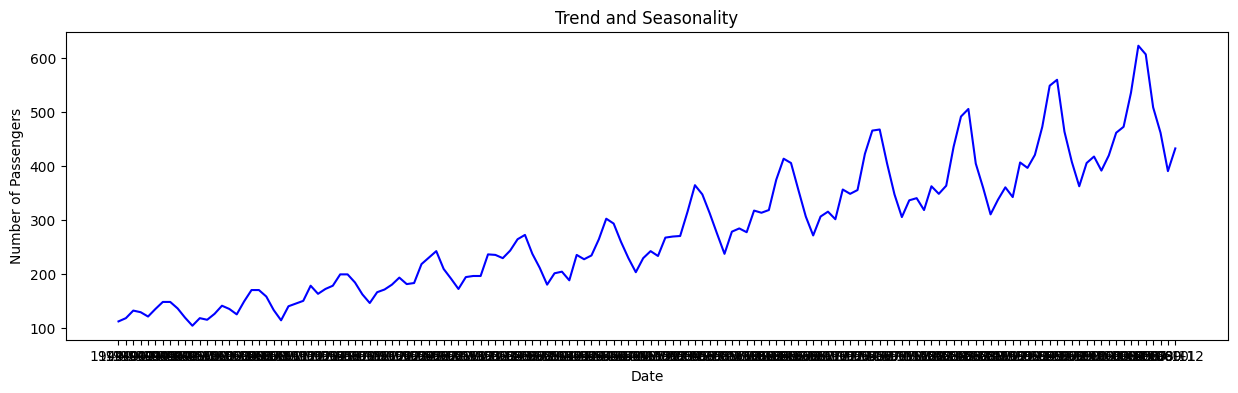

In [ ]:
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Number of Passengers', dpi=100):
    plt.figure(figsize=(15,4), dpi=dpi)
    plt.plot(x, y, color='blue')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()


plot_df(df, x=df['Date'], y=df['Number of Passengers'], title='Trend and Seasonality')

Comportamiento cíclico Otra cosa importante a considerar es el comportamiento cíclico. Ocurre cuando el patrón de subida y bajada de la serie no ocurre en intervalos fijos basados en el calendario. No debemos confundir efecto 'cíclico' con efecto 'estacional'. Si los patrones no son de frecuencias fijas basadas en el calendario, entonces es cíclico. Porque, a diferencia de la estacionalidad, los efectos cíclicos suelen estar influenciados por otros factores no estacionales como el clima.

Por ejemplo la perdida y ganancia de inmunidad en una población durante una epidémia.

## **Series temporales aditivas y multiplicativas**

Podemos tener diferentes combinaciones de tendencias y estacionalidad.
Dependiendo de la naturaleza de las tendencias y la estacionalidad, una serie de tiempo se puede modelar como una serie de tiempo **aditiva** o **multiplicativa**.

Cada observación en la serie se puede expresar como una suma o un producto de los componentes.

 - **Serie temporal aditiva:**

  Valor = Nivel base + Tendencia + Estacionalidad + Error
  
 - **Serie temporal multiplicativa:**

  Valor = Nivel base x Tendencia x Estacionalidad x Error

## **Descomposición de una serie temporal**

La descomposición de una serie temporal se puede realizar considerando la serie como una combinación aditiva o multiplicativa del nivel base, la tendencia, el índice estacional y el término residual.

El *season_decompose* en *statsmodels* implementa esto convenientemente.

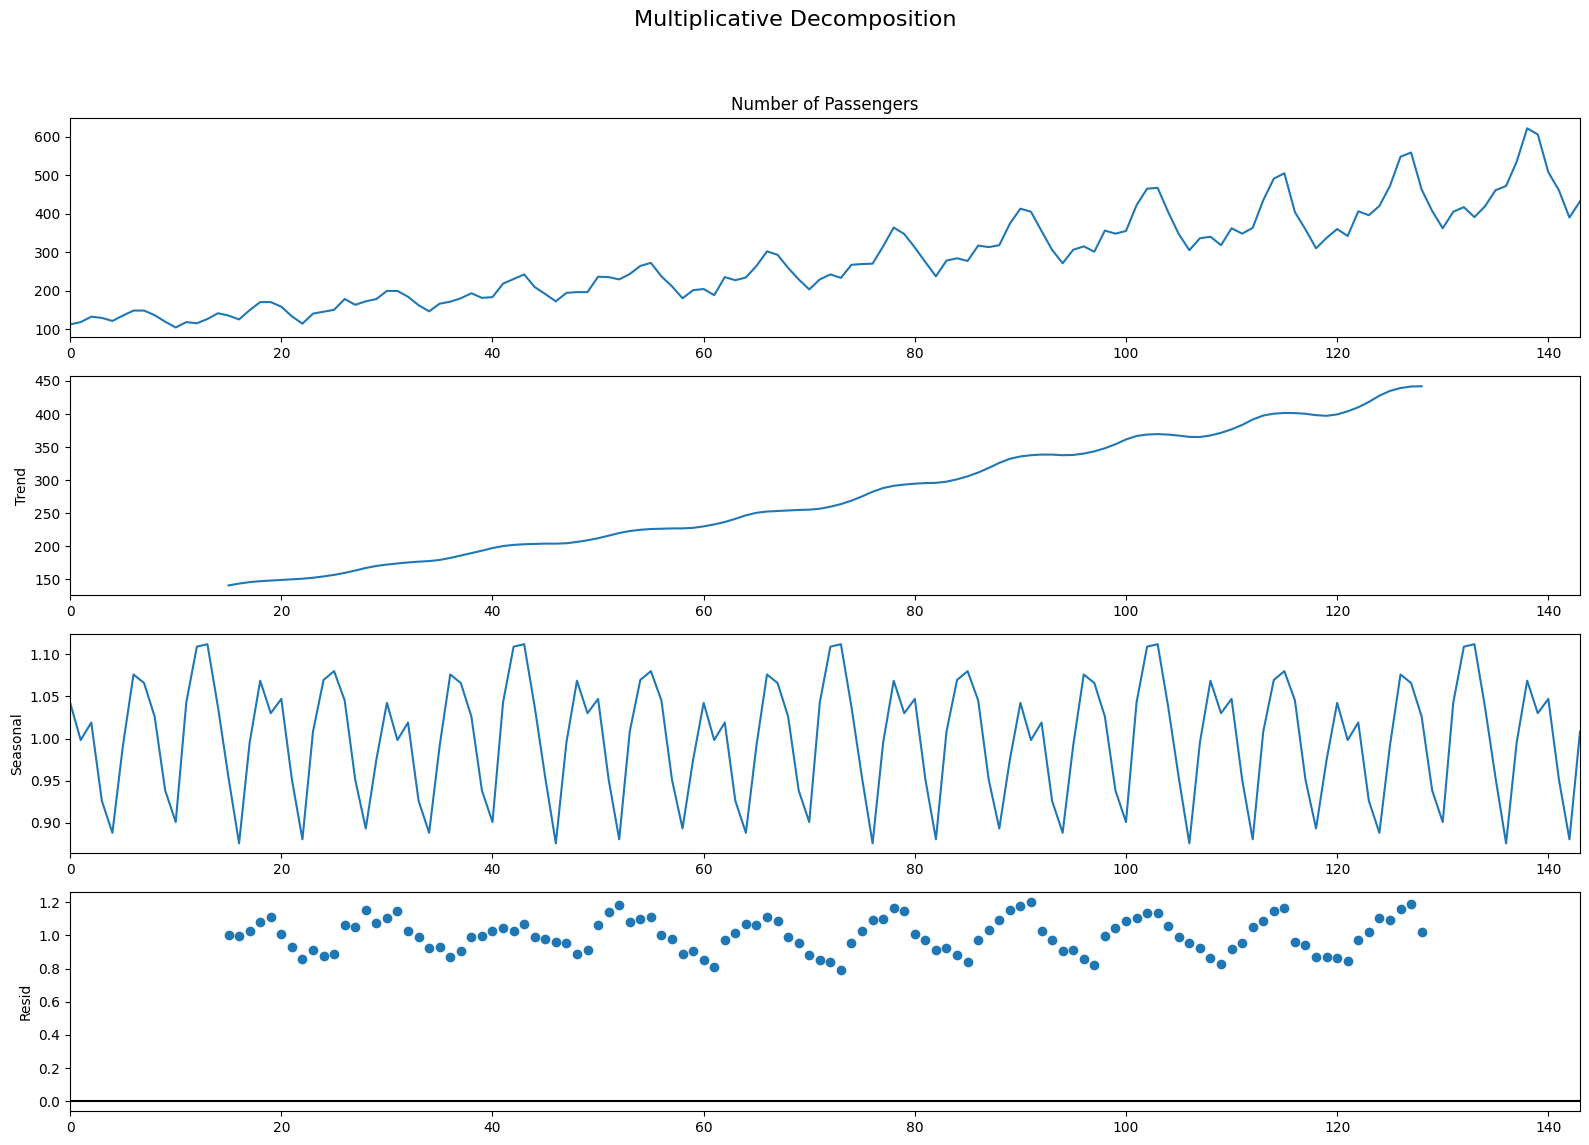

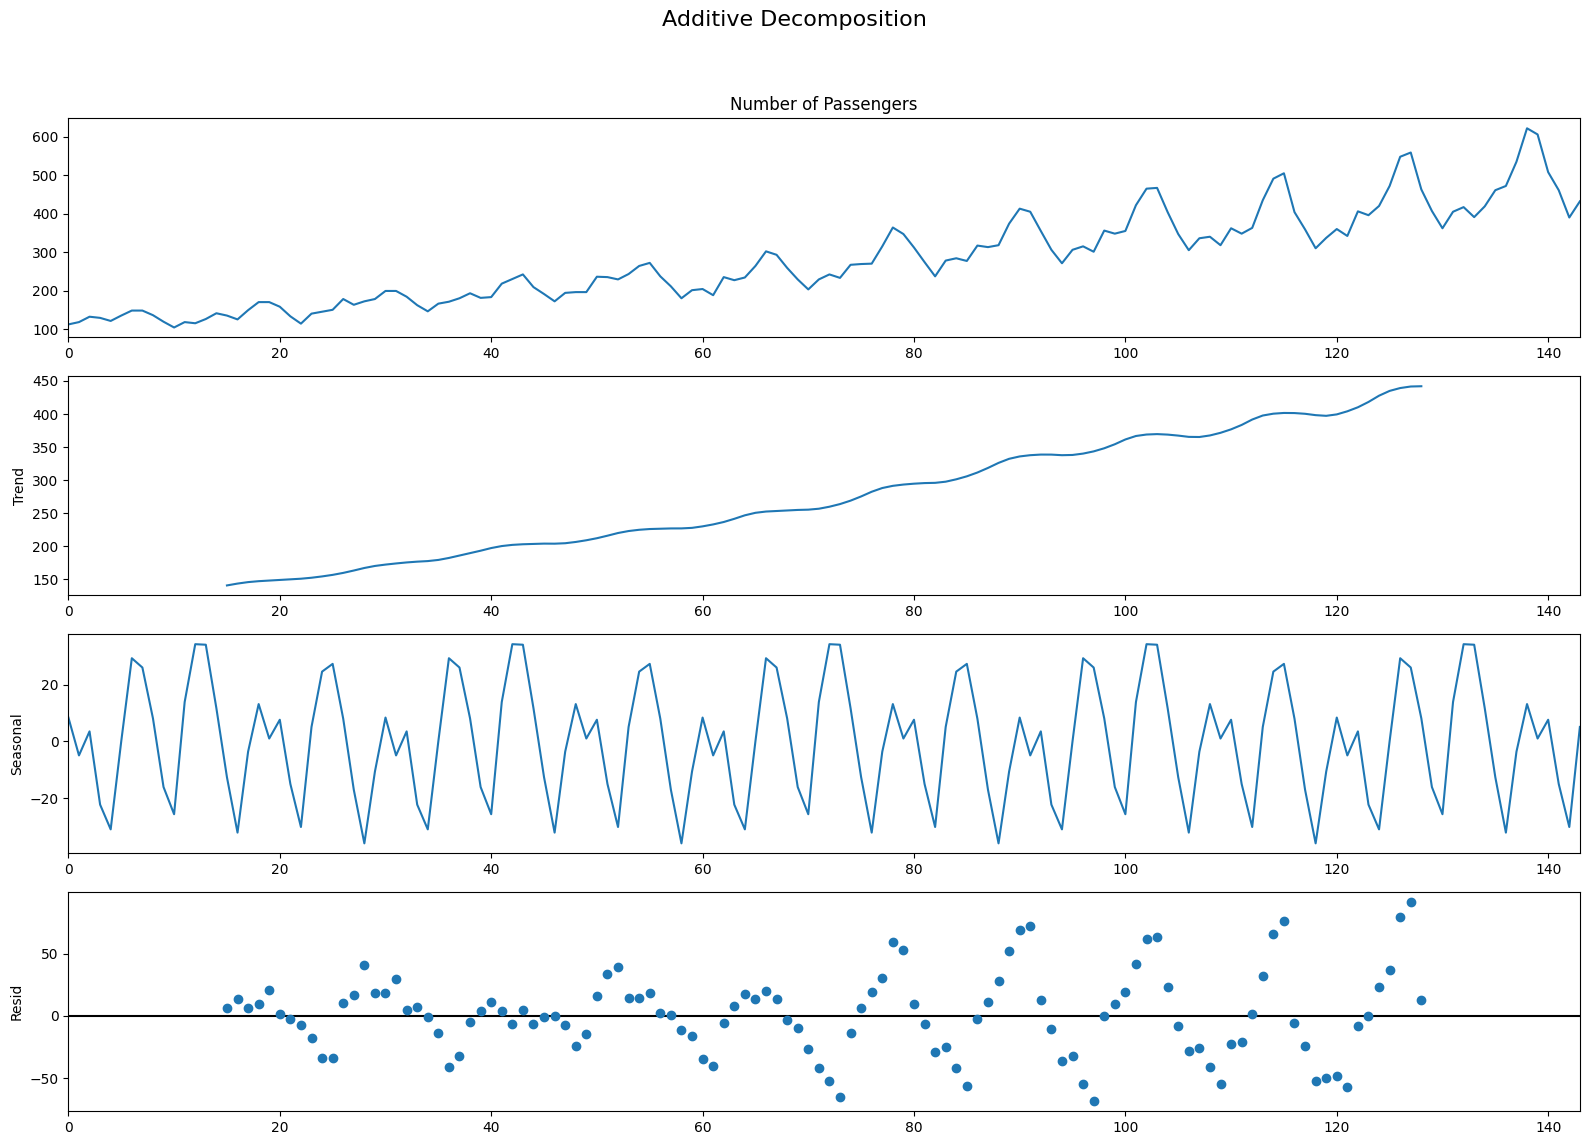

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse


# Multiplicative Decomposition
multiplicative_decomposition = seasonal_decompose(df['Number of Passengers'], model='multiplicative', period=30)

# Additive Decomposition
additive_decomposition = seasonal_decompose(df['Number of Passengers'], model='additive', period=30)

# Plot
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

additive_decomposition.plot().suptitle('Additive Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

Si observamos detenidamente los residuos de la descomposición aditiva, queda algún patrón. La descomposición multiplicativa parece bastante aleatoria, lo cual es bueno. Entonces, idealmente, se debería preferir la descomposición multiplicativa para esta serie en particular.

Para mas detalles ver: https://timeseriesreasoning.com/contents/time-series-decomposition/

## **Series temporales estacionarias y no estacionarias**

Una serie estacionaria es aquella en la que los valores de la serie no son una función del tiempo.

Por lo tanto, los valores son independientes del tiempo. Por lo tanto, las propiedades estadísticas de la serie, como la media, la varianza y la autocorrelación, son constantes en el tiempo.

La autocorrelación de la serie no es más que la correlación de la serie con sus valores anteriores. Una serie temporal estacionaria también es independiente de los efectos estacionales. Ahora, trazaremos algunos ejemplos de series de tiempo estacionarias y no estacionarias para mayor claridad.

<img src='https://www.machinelearningplus.com/wp-content/uploads/2019/02/stationary-and-non-stationary-time-series-865x569.png?ezimgfmt=ng:webp/ngcb1'>

Fuente: https://www.machinelearningplus.com/wp-content/uploads/2019/02/stationary-and-non-stationary-time-series-865x569.png?ezimgfmt=ng:webp/ngcb1



## **¿Cómo hacer que una serie de tiempo sea estacionaria?**

Podemos aplicar algún tipo de transformación para hacer que la serie temporal sea estacionaria.

Estas transformaciones pueden incluir:

- Diferenciar la serie (una o más veces)

- Tomar el logaritmo de la serie

- Sacar la raíz enésima de la serie

- Combinación de los anteriores

El método más comúnmente usado y conveniente para estacionarizar la serie es diferenciar la serie al menos una vez hasta se vuelve aproximadamente estacionario.

## **Introducción a la diferenciación**

Si $Y_t$ es el valor en el tiempo $t$, entonces la primera diferencia de $Y = Y_t – Y_{t-1}$.

En términos más simples, diferenciar la serie no es más que restar el siguiente valor por el valor actual.

Si la primera diferencia no hace que una serie sea estacionaria, podemos optar por la segunda diferencia y así sucesivamente. Por ejemplo, considere la siguiente serie: $[1, 5, 2, 12, 20]$.
- La primera diferencia da: $[5-1, 2-5, 12-2, 20-12] = [4, -3, 10, 8 ]$.
- La segunda diferencia da: $[-3-4, -10-3, 8-10] = [-7, -13, -2]$


## **Razones para convertir una serie no estacionaria en estacionaria antes de pronosticar**

-  Pronosticar una serie estacionaria es relativamente fácil y los pronósticos son más confiables.

- Una razón importante es que los modelos de pronóstico autorregresivos son esencialmente modelos de regresión lineal que utilizan los retrasos de la serie en sí como predictores.

Sabemos que la regresión lineal funciona mejor si los predictores (X variables) no están correlacionados entre sí. Por lo tanto, estacionarizar la serie resuelve este problema ya que elimina cualquier autocorrelación persistente, lo que hace que los predictores (retrasos de la serie) en los modelos de pronóstico sean casi independientes.

## **¿Cómo probar la estacionariedad?**

La estacionariedad de una serie se puede verificar observando la trama de la serie.

Otro método es dividir la serie en 2 o más partes contiguas y calcular las estadísticas de resumen como la media, la varianza y la autocorrelación. Si las estadísticas son bastante diferentes, es poco probable que la serie sea estacionaria.

Hay varios métodos cuantitativos que podemos usar para determinar si una serie dada es estacionaria o no. Esto se puede hacer usando pruebas estadísticas llamadas pruebas de raíz unitaria. Esta prueba verifica si una serie de tiempo no es estacionaria y posee una raíz unitaria. Existen múltiples implementaciones de pruebas de raíz unitaria como:

1. Prueba Dickey Fuller aumentada (prueba ADF)

2. Prueba Kwiatkowski-Phillips-Schmidt-Shin – KPSS (tendencia estacionaria)

3. Prueba Philips Perron (prueba PP)

## **Prueba de Dickey Fuller aumentada (prueba ADF)**

La prueba Dickey Fuller aumentada o (prueba ADF) es la prueba más utilizada para detectar la estacionariedad.

Aquí, asumimos que la hipótesis nula es que la serie de tiempo posee una raíz unitaria y no es estacionaria. Luego, recopilamos evidencia para apoyar o rechazar la hipótesis nula.

Entonces, si encontramos que el valor p en la prueba ADF es menor que el nivel de significancia (0.05), rechazamos la hipótesis nula.

Para obtener más información sobre la prueba ADF vea

- https://en.wikipedia.org/wiki/Augmented_Dickey%E2%80%93Fuller_test

- https://www.machinelearningplus.com/time-series/augmented-dickey-fuller-test/

- https://machinelearningmastery.com/time-series-data-stationary-python/

- http://www.insightsbot.com/augmented-dickey-fuller-test-in-python/

- https://nwfsc-timeseries.github.io/atsa-labs/sec-boxjenkins-aug-dickey-fuller.html

- https://www.statisticshowto.com/adf-augmented-dickey-fuller-test/



## **Kwiatkowski-Phillips-Schmidt-Shin – Prueba KPSS (tendencia estacionaria)**

La prueba KPSS, por otro lado, se utiliza para probar la estacionariedad de la tendencia. La hipótesis nula y la interpretación del valor P es justo lo contrario de la prueba ADH. Si estas interesado en ver mas sobre la prueba puedes obtener más información sobre la prueba KPSS en los siguientes enlaces:

- https://en.wikipedia.org/wiki/KPSS_test

- https://www.machinelearningplus.com/time-series/kpss-test-for-stationarity/

- https://www.statisticshowto.com/kpss-test/

- https://nwfsc-timeseries.github.io/atsa-labs/sec-boxjenkins-kpss.html


## **Philips Perron test (PP Test)**

La prueba de Philips Perron o PP es una prueba de raíz unitaria. Se utiliza en el análisis de series de tiempo para probar la **hipótesis nula de que una serie de tiempo está integrada de orden 1**. Se basa en la prueba ADF discutida anteriormente.

Para más información sobre la prueba de PP, podemos echar un vistazo a los siguientes enlaces:

- https://en.wikipedia.org/wiki/Phillips%E2%80%93Perron_test

- https://www.mathworks.com/help/econ/pptest.html

- https://people.bath.ac.uk/hssjrh/Phillips%20Perron.pdf

- https://www.stata.com/manuals13/tspperron.pdf

## **Diferencia entre ruido blanco y una serie estacionaria**

Como una serie estacionaria, el **ruido blanco** tampoco es una función del tiempo. Por lo tanto, **su media y varianza no cambian con el tiempo**. Pero la diferencia es que **el ruido blanco es completamente aleatorio** con una **media de 0**. En el ruido blanco no hay patrón.

Matemáticamente, *una secuencia de números completamente aleatorios con media cero es un ruido blanco*.

<Axes: title={'center': 'Random White Noise'}>

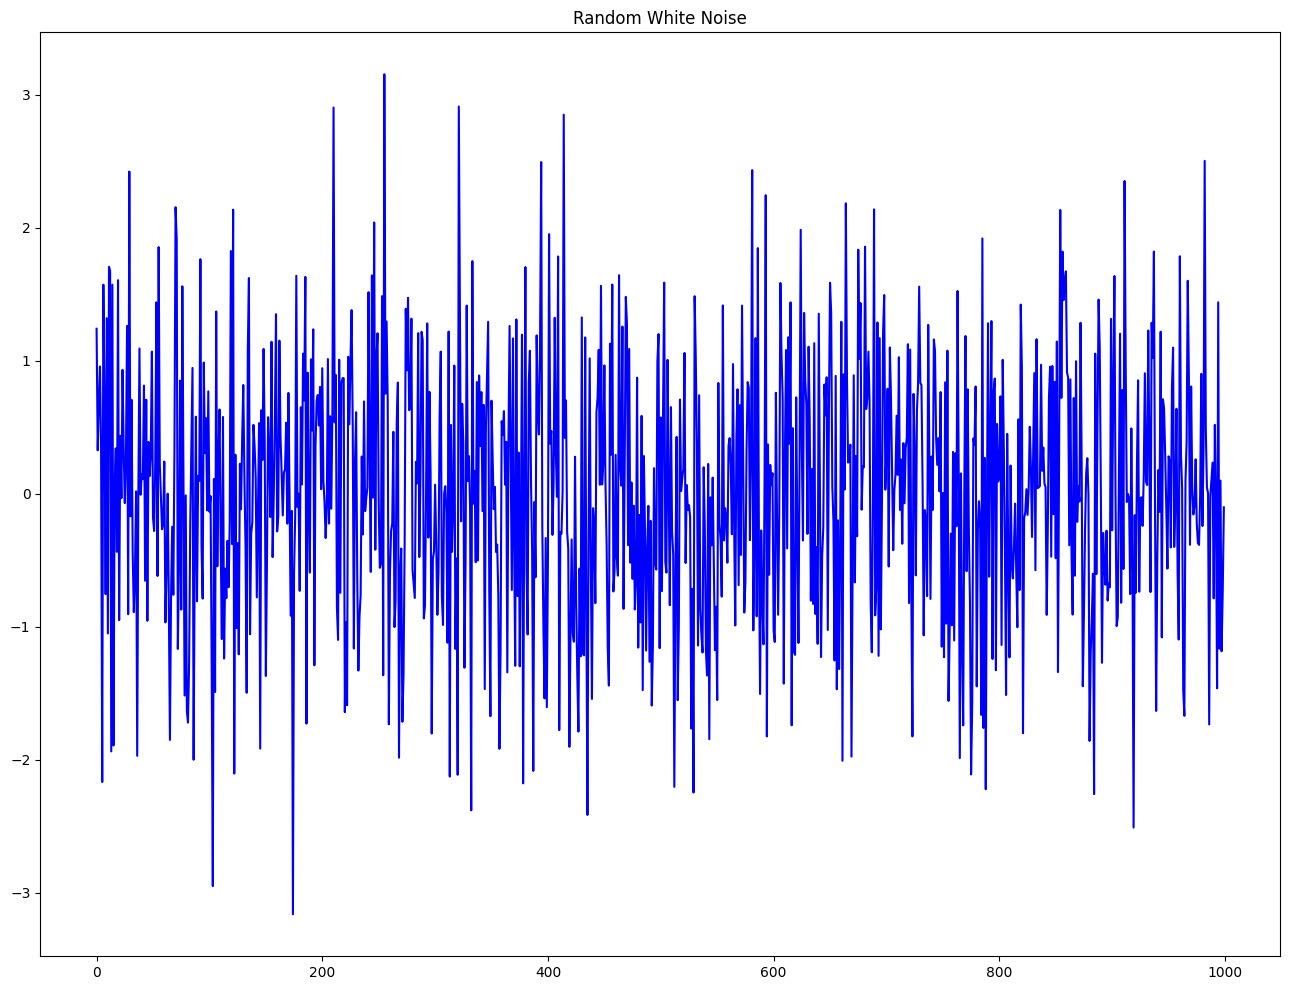

In [ ]:
rand_numbers = np.random.randn(1000)
pd.Series(rand_numbers).plot(title='Random White Noise', color='b')

## **Eliminar la tendencia de una serie temporal**

 Hay varios enfoques para hacer esto, como se indica a continuación:

  - Reste la línea de mejor ajuste de la serie temporal. La línea de mejor ajuste se puede obtener a partir de un modelo de regresión lineal con los pasos de tiempo como predictor.
  
  - Para tendencias más complejas, podemos querer usar términos cuadráticos (x^2) en el modelo. Restamos el componente de tendencia obtenido de la descomposición de series temporales.
  
  - Restar la media. Aplique un filtro como el filtro Baxter-King (statsmodels.tsa.filters.bkfilter) o el filtro Hodrick-Prescott (statsmodels.tsa.filters.hpfilter) para eliminar las líneas de tendencia del promedio móvil o los componentes cíclicos.
  
  Veamos los métodos para eliminar la tendencia de una serie de tiempo.



Text(0.5, 1.0, 'Air Passengers detrended by subtracting the least squares fit')

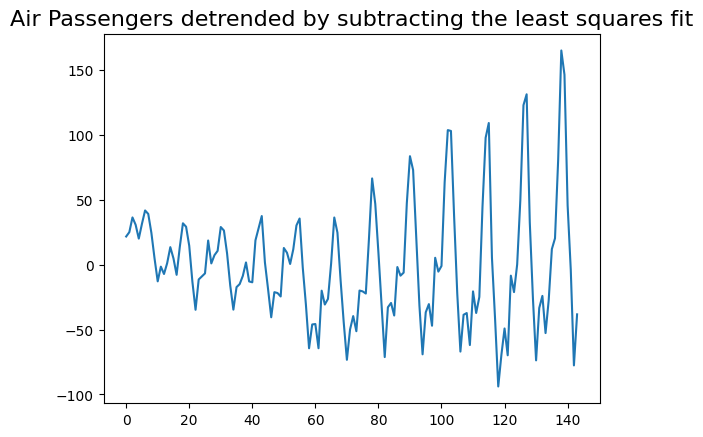

In [ ]:
# Using scipy: Subtract the line of best fit
from scipy import signal
detrended1 = signal.detrend(df['Number of Passengers'].values)
plt.plot(detrended1)
plt.title('Air Passengers detrended by subtracting the least squares fit', fontsize=16)

Text(0.5, 1.0, 'Air Passengers detrended by subtracting the trend component')

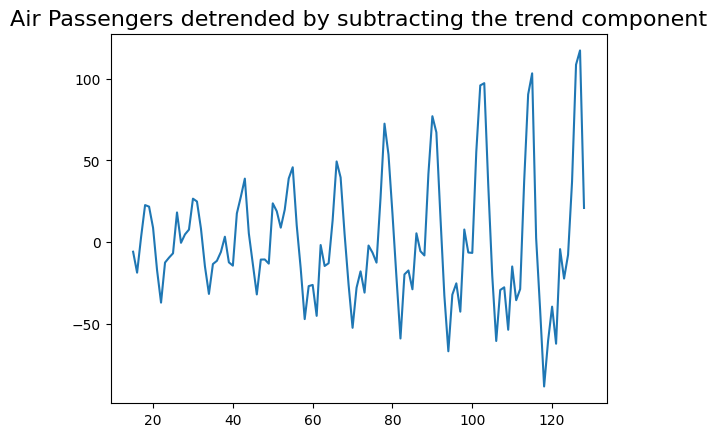

In [ ]:
# Using statmodels: Subtracting the Trend Component
from statsmodels.tsa.seasonal import seasonal_decompose
result_mul = seasonal_decompose(df['Number of Passengers'], model='multiplicative', period=30)
detrended2 = df['Number of Passengers'].values - result_mul.trend
plt.plot(detrended2)
plt.title('Air Passengers detrended by subtracting the trend component', fontsize=16)

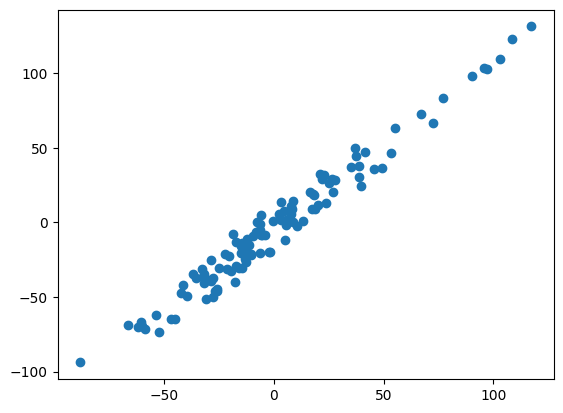

In [ ]:
plt.scatter(detrended2,detrended1)

## **Desestacionalizar una serie temporal**

Los enfoques se enumeran a continuación:

1. Tome un promedio móvil con la longitud como la ventana estacional. Esto suavizará en serie en el proceso.
2. Diferencia estacional de la serie (restar el valor de la temporada anterior del valor actual).
3. Divida la serie por el índice estacional obtenido de la descomposición STL.
4. Si dividir por el índice estacional no funciona bien, tomaremos un logaritmo de la serie y luego desestacionalizaremos.
5. Más tarde restauraremos a la escala original tomando una exponencial.

[]

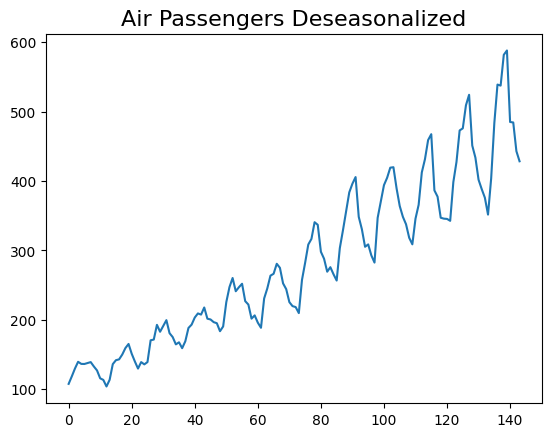

In [ ]:
# Subtracting the Trend Component


# Time Series Decomposition
result_mul = seasonal_decompose(df['Number of Passengers'], model='multiplicative', period=30)


# Deseasonalize
deseasonalized = df['Number of Passengers'].values / result_mul.seasonal


# Plot
plt.plot(deseasonalized)
plt.title('Air Passengers Deseasonalized', fontsize=16)
plt.plot()

## **¿Cómo probar la estacionalidad de una serie temporal?**

La forma común de probar la estacionalidad de una serie de tiempo es graficar la serie y buscar patrones repetibles en intervalos de tiempo fijos.

Entonces, los tipos de estacionalidad están determinados por el reloj o el calendario. Hora del día, Día del mes, Semanal, Mensual o Anual.

Sin embargo, si queremos una inspección más definitiva de la estacionalidad, utilice el gráfico de **función de autocorrelación (ACF)**.

Si hay un fuerte patrón estacional, el gráfico ACF generalmente revela picos repetidos definitivos en los múltiplos de la ventana estacional.

Alternativamente, si queremos una prueba estadística, CHTest puede determinar si se requiere diferenciación estacional para estacionarizar la serie.

**CHTest** La prueba de Canova-Hansen para las diferencias estacionales. Canova y Hansen (1995) propusieron un estadístico de prueba para la hipótesis nula de que el patrón estacional es estable. La estadística de prueba se puede formular en términos de dummies estacionales o ciclos estacionales. El primero nos permite identificar temporadas (por ejemplo, meses o trimestres) que no son estables, mientras que el segundo prueba la estabilidad de los ciclos estacionales (por ejemplo, ciclos del período 2 y 4 trimestres en datos trimestrales). https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.CHTest.html#pmdarima.arima.CHTest

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

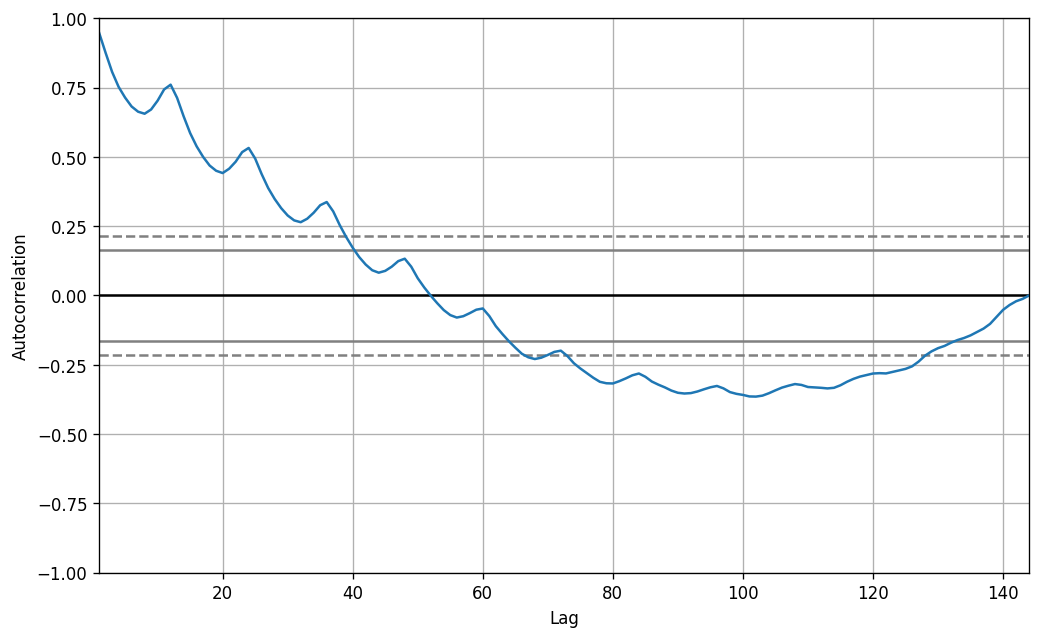

In [ ]:
# Test for seasonality
from pandas.plotting import autocorrelation_plot

# Draw Plot
plt.rcParams.update({'figure.figsize':(10,6), 'figure.dpi':120})
autocorrelation_plot(df['Number of Passengers'].tolist())

## **Funciones de autocorrelación y autocorrelación parcial**

- **La autocorrelación** es simplemente la correlación de una serie con sus propios retrasos. Si una serie está significativamente autocorrelacionada, eso significa que los valores anteriores de la serie (retrasos) pueden ser útiles para predecir el valor actual.

- **La autocorrelación parcial** también transmite información similar pero transmite la correlación pura de una serie y su rezago, excluyendo las contribuciones de correlación de los rezagos intermedios.

/usr/local/lib/python3.10/dist-packages/statsmodels/graphics/tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


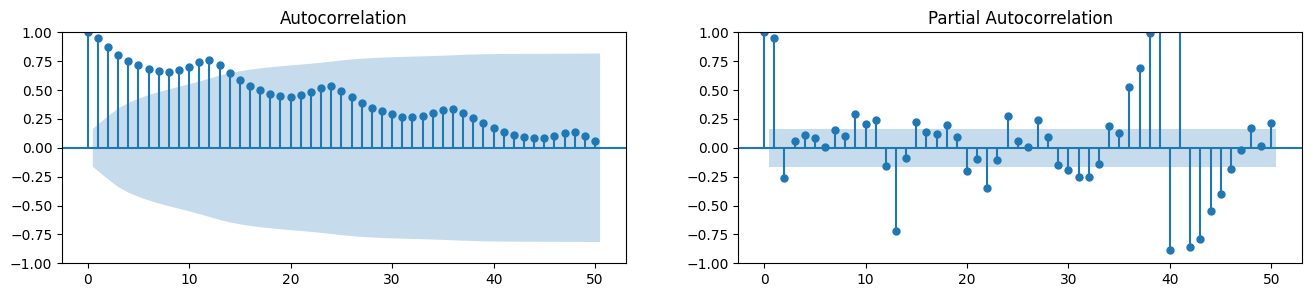

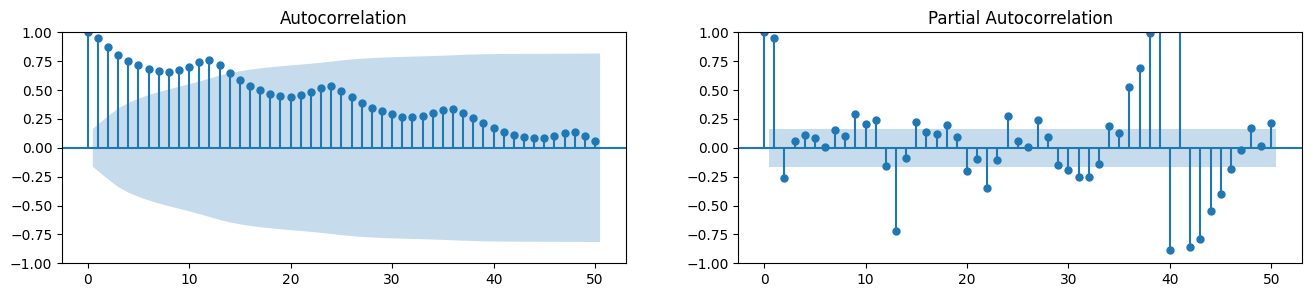

In [ ]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Draw Plot
fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(df['Number of Passengers'].tolist(), lags=50, ax=axes[0])
plot_pacf(df['Number of Passengers'].tolist(), lags=50, ax=axes[1])

## **Cálculo de la función de autocorrelación parcial**

La función de autocorrelación parcial de retraso (k) de una serie es el coeficiente de ese retraso en la ecuación de autorregresión de Y. La ecuación autorregresiva de Y no es más que la regresión lineal de Y con sus propios retrasos como predictores. Por ejemplo, si $Y_t$ es la serie actual e $Y_{t-1}$ es el rezago 1 de Y, entonces la autocorrelación parcial del rezago 3 ($Y_{t-3}$) es el coeficiente $α_3$ de $Y_{t-3}$ en la siguiente ecuación:

<img src='https://www.machinelearningplus.com/wp-content/uploads/2019/02/12_5_Autoregression_Equation-min.png?ezimgfmt=ng:webp/ngcb1'>

Fuente: https://www.machinelearningplus.com/wp-content/uploads/2019/02/12_5_Autoregression_Equation-min.png?ezimgfmt=ng:webp/ngcb1



## **Gráficos de retraso**

Un diagrama de retraso es un diagrama de dispersión de una serie de tiempo contra un retraso de sí mismo. Normalmente se utiliza para comprobar la autocorrelación. Si existe algún patrón en la serie, la serie se autocorrelaciona. Si no existe tal patrón, es probable que la serie sea un ruido blanco aleatorio.

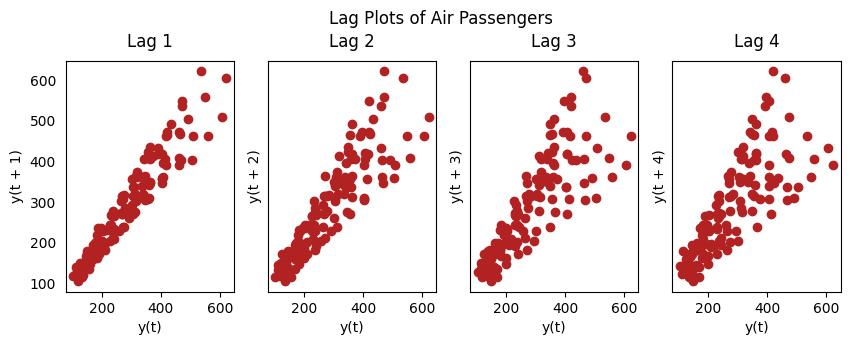

In [ ]:
from pandas.plotting import lag_plot
plt.rcParams.update({'ytick.left' : False, 'axes.titlepad':10})

# Plot
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(df['Number of Passengers'], lag=i+1, ax=ax, c='firebrick')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle('Lag Plots of Air Passengers', y=1.05)
plt.show()

Veamos un ejemplo con ruido blanco:

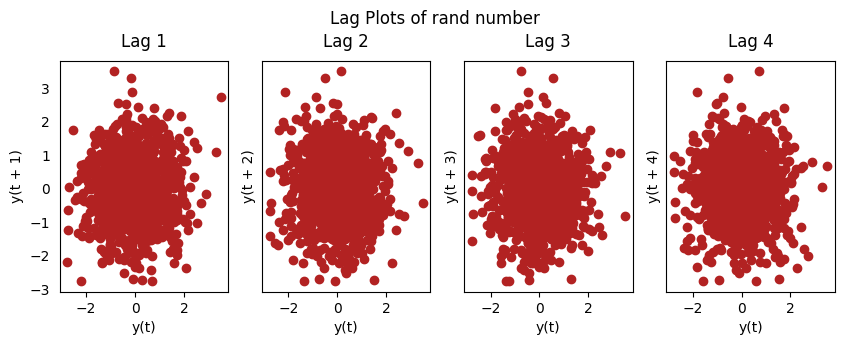

In [ ]:
rand_numbers = np.random.randn(1000)

plt.rcParams.update({'ytick.left' : False, 'axes.titlepad':10})

# Plot
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(pd.Series(rand_numbers), lag=i+1, ax=ax, c='firebrick')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle('Lag Plots of rand number', y=1.05)
plt.show()

## **Prueba de causalidad de Granger**

**La prueba de *causalidad de Granger* se usa para determinar si una serie de tiempo será útil para pronosticar otra.**

Se basa en la idea de que si X causa Y, entonces el pronóstico de Y basado en valores previos de Y, y los valores previos de X deberían superar el pronóstico de Y basado solo en valores previos de Y.

Por lo tanto, la prueba de causalidad de Granger no debe usarse para probar si un retraso de Y causa Y. En cambio, generalmente se usa solo en **variables exógenas (no retraso Y)**.

Está implementado en el paquete statsmodel. Acepta una matriz 2D con 2 columnas como argumento principal. Los valores están en la primera columna y el predictor (X) está en la segunda columna.

- La hipótesis Nula es que la serie de la segunda columna, no causa Granger la serie de la primera. Si los valores P son menores que un nivel de significación (0,05), rechazamos la hipótesis nula y *concluimos que dicho retraso de X es realmente útil*. El segundo argumento maxlag dice hasta cuántos retrasos de Y deben incluirse en la prueba.

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np
data = sm.datasets.macrodata.load_pandas()
data = data.data[["realgdp", "realcons"]].pct_change().dropna()

print(data)

# All lags up to 4

gc_res = grangercausalitytests(data, 4)

# Only lag 4

gc_res = grangercausalitytests(data, [4])

      realgdp  realcons
1    0.025256  0.015404
2   -0.001192  0.010440
3    0.003501  0.001085
4    0.022438  0.009580
5   -0.004674  0.012652
..        ...       ...
198 -0.006758 -0.008908
199 -0.013710 -0.007812
200 -0.016475  0.001512
201 -0.001850 -0.002193
202  0.006886  0.007291

[202 rows x 2 columns]

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=28.7248 , p=0.0000  , df_denom=198, df_num=1
ssr based chi2 test:   chi2=29.1600 , p=0.0000  , df=1
likelihood ratio test: chi2=27.2295 , p=0.0000  , df=1
parameter F test:         F=28.7248 , p=0.0000  , df_denom=198, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=18.9880 , p=0.0000  , df_denom=195, df_num=2
ssr based chi2 test:   chi2=38.9498 , p=0.0000  , df=2
likelihood ratio test: chi2=35.5873 , p=0.0000  , df=2
parameter F test:         F=18.9880 , p=0.0000  , df_denom=195, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=13.5015 , 

Los conceptos y el código de este cuaderno se tomaron de los siguientes sitios web:

- https://www.machinelearningplus.com/time-series/time-series-analysis-python/
- https://towardsdatascience.com/an-end-to-end-project-on-time-series-analysis-and-forecasting-with-python-4835e6bf050b
- https://towardsdatascience.com/time-series-analysis-in-python-an-introduction-70d5a5b1d52a
- https://www.digitalocean.com/community/tutorials/a-guide-to-time-series-visualization-with-python-3
- https://www.kaggle.com/code/prashant111/complete-guide-on-time-series-analysis-in-python#20.-Smoothening-a-Time-Series-

## Desafío: Análisis y modelado de series temporales sintéticas

**Objetivo:** aplicar los conceptos vistos en la notebook sobre limpieza, visualización, descomposición, detección de rupturas, imputación y modelado predictivo usando datos simulados.

**Tareas sugeridas**
- Visualizar la serie y sus componentes (tendencia, estacionalidad, ruido).
- Detectar y localizar rupturas estructurales y outliers.
- Imputar valores faltantes y justificar el método elegido.
- Ajustar al menos dos modelos de pronóstico (por ejemplo ARIMA/SARIMA y un modelo basado en regresión o Prophet).
- Evaluar y comparar el desempeño con métricas apropiadas.
- (Opcional) Crear un modelo multivariante usando las covariables simuladas.

**Entrega**
- Notebook con gráficos, código y breves conclusiones para cada paso.
- Responder: ¿qué método de imputación funcionó mejor y por qué? ¿qué modelo generalizó mejor y por qué?


In [ ]:
# Generador de datos sintéticos para el desafío de series temporales
import numpy as np
import pandas as pd

np.random.seed(42)

# Parámetros
n_days = 4 * 365  # ~4 años diarios
date_index = pd.date_range(start="2018-01-01", periods=n_days, freq="D")

# Componentes
trend = 0.0008 * np.arange(n_days)                      # tendencia lineal suave
seasonality_yearly = 10 * np.sin(2 * np.pi * np.arange(n_days) / 365.25)
seasonality_weekly = 2 * np.sin(2 * np.pi * np.arange(n_days) / 7)
noise = np.random.normal(scale=1.5, size=n_days)

# Autoregresivo simple para dar dependencia temporal
phi = 0.6
ar = np.zeros(n_days)
for t in range(1, n_days):
    ar[t] = phi * ar[t-1] + np.random.normal(scale=0.5)

# Covariables sintéticas (exógenas)
x1 = 0.5 * np.arange(n_days) / n_days + 3 * np.cos(2 * np.pi * np.arange(n_days) / 365.25) + np.random.normal(scale=0.3, size=n_days)
x2 = np.random.choice([0, 1], size=n_days, p=[0.9, 0.1])  # indicador de eventos raros

# Serie principal
y = 50 + trend + seasonality_yearly + seasonality_weekly + ar + noise + 0.8 * x1 + 5 * x2

# Introducir missing values aleatorios
missing_idx = np.random.choice(n_days, size=int(0.03 * n_days), replace=False)
y_with_nans = y.copy()
y_with_nans[missing_idx] = np.nan

# Introducir outliers
outlier_idx = np.random.choice(n_days, size=10, replace=False)
y_with_nans[outlier_idx] += np.random.choice([20, -25], size=10)

# Introducir un cambio estructural (shift) en la tendencia a mitad del periodo
change_point = int(n_days * 0.55)
y_with_nans[change_point:] += 8  # salto positivo sostenido

# Construir DataFrame
df = pd.DataFrame({
    "ds": date_index,
    "y": y_with_nans,
    "x1": x1,
    "x2": x2
})
df = df.set_index("ds")

# Resumen rápido
print("Datos generados:", df.shape)
print("Rango de fechas:", df.index.min(), "a", df.index.max())
print("Missing:", df['y'].isna().sum(), "Outliers introducidos:", len(outlier_idx))
df.head()
